In [2]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import tf_keras as keras

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sksurv.metrics import integrated_brier_score
from sksurv.util import Surv

tf.keras.backend.set_floatx("float32")
tfd = tfp.distributions

BASE_DIR = Path.cwd()

BEST_LR = 0.01
EPOCHS = 100
PATIENCE = 10
TEST_SIZE = 0.2
RANDOM_STATE = 42


In [3]:
fracture_file = BASE_DIR / "IR-Rail-Fracture-Data.csv"
master_files = [
    BASE_DIR / "RAIL_MASTER_PRYJ_WITH_USFD_INSPDATE.xlsx",
    BASE_DIR / "RAIL_MATSER_NCR_AGRA_15_10_2025.xlsx",
    BASE_DIR / "RAIL_MASTER_WITH_USFD_INSPDATE_FILLED.xlsx",
]

for file_path in [fracture_file, *master_files]:
    print(f"{file_path.name}: {'FOUND' if file_path.exists() else 'MISSING'}")

df_NCR_PRYJ = pd.read_excel(master_files[0])
df_NCR_AGRA = pd.read_excel(master_files[1])
df_NCR_JHS = pd.read_excel(master_files[2])
df_master = pd.concat([df_NCR_AGRA, df_NCR_JHS, df_NCR_PRYJ], ignore_index=True)

df_fracture = pd.read_csv(fracture_file)

print("Master shape:", df_master.shape)
print("Fracture shape:", df_fracture.shape)


IR-Rail-Fracture-Data.csv: FOUND
RAIL_MASTER_PRYJ_WITH_USFD_INSPDATE.xlsx: FOUND
RAIL_MATSER_NCR_AGRA_15_10_2025.xlsx: FOUND
RAIL_MASTER_WITH_USFD_INSPDATE_FILLED.xlsx: FOUND
Master shape: (126969, 22)
Fracture shape: (12113, 24)


In [4]:
# Master-data preprocessing copied from the original notebook

df_master = df_master.drop(columns=['Unnamed: 17', 'KMTO', 'METTO', 'RAIL_LENGTH_IN_MET', 'RLYCODE'])
df_master['Kilometerage'] = df_master['KMFROM'] + (df_master['METFROM'] / 1000)
df_master['Kilometerage'] = df_master['Kilometerage'].round(3)
df_master = df_master.drop(columns=['KMFROM', 'METFROM'])

df_master.loc[~df_master['LINE'].isin(['UP', 'DN', 'SL']), 'LINE'] = 'OTH'
df_master = df_master[df_master['RAIL_SECTION'] != 'OTHER'].copy()

df_master['LAYING_DATE'] = pd.to_datetime(
    df_master['DATE_OF_LAYING'],
    format='mixed',
    errors='coerce'
)
df_master = df_master.drop(columns=['DATE_OF_LAYING'])

df_master['USFDTIMESTAMP'] = df_master['INSPDATE']
df_master = df_master.drop(columns=['INSPDATE'])

df_master['USFDCLASSIFICATION'] = df_master['USFD_CLASSIFICATION']
df_master = df_master.drop(columns=['USFD_CLASSIFICATION'])

df_master['LAYING_DATE'] = pd.to_datetime(
    df_master['LAYING_DATE'],
    format='%b-%Y',
    errors='coerce'
)

df_master['USFDTIMESTAMP'] = (
    df_master['USFDTIMESTAMP']
    .astype(str)
    .str[:10]
)

df_master['USFDTIMESTAMP'] = pd.to_datetime(
    df_master['USFDTIMESTAMP'],
    errors='coerce'
)

df_master.shape


(126919, 16)

In [5]:
# Fracture-data preprocessing copied from the original notebook

df = df_fracture.copy()

if 'DURATION' in df.columns:
    df = df[df['DURATION'] >= 0].copy()

df['Kilometerage'] = df['KM'] + (df['METER'] / 1000)
df['Kilometerage'] = df['Kilometerage'].round(3)

combined_str = (
    df['FRACTURE_DATE'].str[:10]
    + ' '
    + df['FRACTURE_TIME'].str.replace('.', ':', regex=False)
)

df['FRACTURE_TIMESTAMP'] = pd.to_datetime(
    combined_str,
    format='mixed',
    errors='coerce'
)

df['LAYING_DATE'] = pd.to_datetime(df['LAYINGDATE.1'], dayfirst=False, errors='coerce')

df = df.drop(columns=[
    'LAYINGDATE',
    'ASSETTYPE',
    'KM',
    'METER',
    'FRACTURE_DATE',
    'FRACTURE_TIME',
    'LAYINGDATE.1'
])

df['USFDTIMESTAMP'] = pd.to_datetime(
    df['USFDTESTDATE'].str[:10],
    format='%Y-%m-%d',
    errors='coerce'
)
df = df.drop(columns=['USFDTESTDATE'])

df.loc[~df['LINE'].isin(['UP', 'DN', 'SL']), 'LINE'] = 'OTH'
df = df[df['RLYCODE'] == 'NCR'].copy()
df = df.drop(columns=['RLYCODE'])
df = df[df['RAIL_SECTION'] != 'OTHER'].copy()
df = df.drop(columns=['FRACTURE_DATE.1'])

df.shape
print(df.sample(5))

      DIVCODE    SECTION LINE RAIL_SECTION  ANNUAL_GMT  SPEED  GMTCARRIED  \
10095     JHS    AIT BZM   DN         52KG      12.640    110      370.14   
10515     JHS    AIT BZM   DN         52KG      19.680    110      374.62   
6088     PRYJ  PRYJ-CNBI   DN         60KG      27.495    130      596.00   
4633     PRYJ  CAR - COI   DN         60KG      47.810    130      729.96   
4067     PRYJ   PNK--ETW   UP         60KG      79.440    130      683.21   

      USFDCLASSIFICATION LRRR AXLELOAD TRACK_TYPE STRAIGHT_CURVE  \
10095                 GR   LR    22.32        LWR       STRAIGHT   
10515                 GR   LR    22.32        LWR       STRAIGHT   
6088                  GR   RR    22.32        LWR       STRAIGHT   
4633                  GR   LR    22.32        LWR          CURVE   
4067                  GR   RR    22.32        LWR       STRAIGHT   

       SERVICE_LIFE  DURATION  Kilometerage  FRACTURE_TIMESTAMP LAYING_DATE  \
10095           525    7175.0      1289.012 2017-

In [6]:
# Merge fracture and master data exactly as in the source notebook

final_df = pd.concat([df, df_master], ignore_index=True)
final_df = final_df.dropna(subset='ANNUAL_GMT').copy()
final_df['Event'] = final_df['DURATION'].notna().astype(int)

print(final_df.shape)
final_df.sample(5)


(127461, 19)


,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,USFDCLASSIFICATION,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,DURATION,Kilometerage,FRACTURE_TIMESTAMP,LAYING_DATE,USFDTIMESTAMP,Event
17029,AGRA,JAB(W line AF) -BXN,SL,52KG,30.720,110,471.0,OBSJP,LR,22.9,LWR,CURVE,525,NaN,33.182,NaT,2015-07-01,2025-10-14,0
119409,PRYJ,PRYJ-CNBI,DN,60KG,56.630,130,134.0,OBSJP,RR,22.32,SWR,STRAIGHT,800,NaN,991.800,NaT,2022-03-01,2025-09-18,0
84617,PRYJ,CAR - COI,UP,60KG,65.830,130,378.0,OBSJP,LR,22.32,LWR,STRAIGHT,800,NaN,747.375,NaT,2020-02-01,2025-10-11,0
98070,PRYJ,KRJ-GZB,DN,60KG,56.880,130,588.0,OBSJP,LR,22.32,LWR,STRAIGHT,1000,NaN,1415.349,NaT,2013-04-01,2025-08-05,0
7823,AGRA,BTE-BKI,SL,60KG,29.675,110,2.0,OBSJP,LR,22.9,LWR,STRAIGHT,800,NaN,123.942,NaT,2025-10-01,2025-09-24,0


In [7]:
final_df.head(5)


,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,GMTCARRIED,USFDCLASSIFICATION,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,SERVICE_LIFE,DURATION,Kilometerage,FRACTURE_TIMESTAMP,LAYING_DATE,USFDTIMESTAMP,Event
0,JHS,AIT BZM,DN,52KG,12.64,110,4.48,GR,RR,22.32,LWR,STRAIGHT,525,2.0,1256.209,2017-08-03 12:10:00,2017-08-01,2017-05-23,1
1,JHS,KID OHAN,SL,52KG,25.14,100,2.28,GR,LR,22.32,SWR,CURVE,525,2.0,1412.837,2021-02-03 04:10:00,2021-02-01,2020-12-24,1
2,PRYJ,PNK--ETW,UP,60KG,65.44,130,6.62,GR,LR,22.32,LWR,STRAIGHT,800,2.0,1120.743,2019-01-03 06:15:00,2019-01-01,2018-12-12,1
3,PRYJ,CAR - COI,UP,60KG,65.83,130,7.89,GR,LR,22.32,SWR,STRAIGHT,800,3.0,705.311,2019-04-04 09:45:00,2019-04-01,2019-03-13,1
4,PRYJ,CAR - COI,UP,60KG,94.64,130,55.21,GR,LR,22.32,LWR,STRAIGHT,800,3.0,758.095,2017-04-04 13:40:00,2017-04-01,2016-11-21,1


In [8]:
# Encoding and feature engineering copied from the original notebook

ordinal_cols = ['RAIL_SECTION', 'AXLELOAD']
rail_order = ['52KG', '60KG']
axle_order = ['Up to 20.32', '22.32', '22.9', '25']

ohe_cols = [
    'DIVCODE',
    'LINE',
    'USFDCLASSIFICATION',
    'LRRR',
    'TRACK_TYPE',
    'STRAIGHT_CURVE'
]

numeric_cols = [
    'ANNUAL_GMT',
    'SPEED',
    'GMTCARRIED',
    'SERVICE_LIFE',
    'DURATION',
    'Kilometerage',
    'Event'
]

date_cols = [
    'FRACTURE_TIMESTAMP',
    'LAYING_DATE',
    'USFDTIMESTAMP'
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'ord',
            OrdinalEncoder(
                categories=[rail_order, axle_order],
                dtype='float64',
                handle_unknown='use_encoded_value',
                unknown_value=-1,
            ),
            ordinal_cols,
        ),
        (
            'ohe',
            OneHotEncoder(
                drop='first',
                sparse_output=False,
                dtype='float64',
                handle_unknown='ignore',
            ),
            ohe_cols,
        ),
        ('num', 'passthrough', numeric_cols),
        ('date', 'passthrough', date_cols),
    ],
    verbose_feature_names_out=True,
)

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
pipeline.set_output(transform='pandas')

df_processed = pipeline.fit_transform(final_df)

freq_map = final_df['SECTION'].value_counts()
df_processed['SECTION_FREQ'] = final_df['SECTION'].map(freq_map).astype('int64')

bad_cols = df_processed.select_dtypes(include='object').columns
assert len(bad_cols) == 0, f"Object dtype leakage: {bad_cols}"





In [9]:
# 1. Create the column (as you already did)
df_processed["CENSOR_DATE"] = np.where(
    df_processed["num__Event"] == 1,
    df_processed["date__FRACTURE_TIMESTAMP"],
    pd.to_datetime('2025-08-01') 
)

# 2. FORCE the entire new column into a pandas datetime format
df_processed["CENSOR_DATE"] = pd.to_datetime(df_processed["CENSOR_DATE"])

# 3. Now the subtraction will work perfectly
df_processed["DURATION"] = (
    df_processed["CENSOR_DATE"] - df_processed["date__LAYING_DATE"]
).dt.days

df_processed["DURATION"] = df_processed["DURATION"].clip(lower=0)
print(len(df_processed[df_processed["DURATION"] <= 0]))

2751


In [10]:
df_processed = df_processed[df_processed['DURATION'] != 0]
print(len(df_processed[df_processed["DURATION"] <= 0]))

0


In [11]:
df_processed.sample(5)

,ord__RAIL_SECTION,ord__AXLELOAD,ohe__DIVCODE_JHS,ohe__DIVCODE_PRYJ,ohe__LINE_OTH,ohe__LINE_SL,ohe__LINE_UP,ohe__USFDCLASSIFICATION_OBS,ohe__USFDCLASSIFICATION_OBS Joggled Plate,ohe__USFDCLASSIFICATION_OBSJP,...,num__SERVICE_LIFE,num__DURATION,num__Kilometerage,num__Event,date__FRACTURE_TIMESTAMP,date__LAYING_DATE,date__USFDTIMESTAMP,SECTION_FREQ,CENSOR_DATE,DURATION
92558,1.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1000,NaN,1199.039,0,NaT,2023-12-01,2025-08-12,2506,2025-08-01,609
13671,1.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1000,NaN,1319.310,0,NaT,2014-05-01,2025-09-24,4274,2025-08-01,4110
41748,1.0,-1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,800,NaN,1268.551,0,NaT,2022-11-01,2025-01-09,4434,2025-08-01,1004
100475,1.0,-1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1000,NaN,1411.997,0,NaT,2010-07-01,2025-04-24,7060,2025-08-01,5510
108619,1.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,800,NaN,824.066,0,NaT,2025-06-01,2025-09-26,726,2025-08-01,61


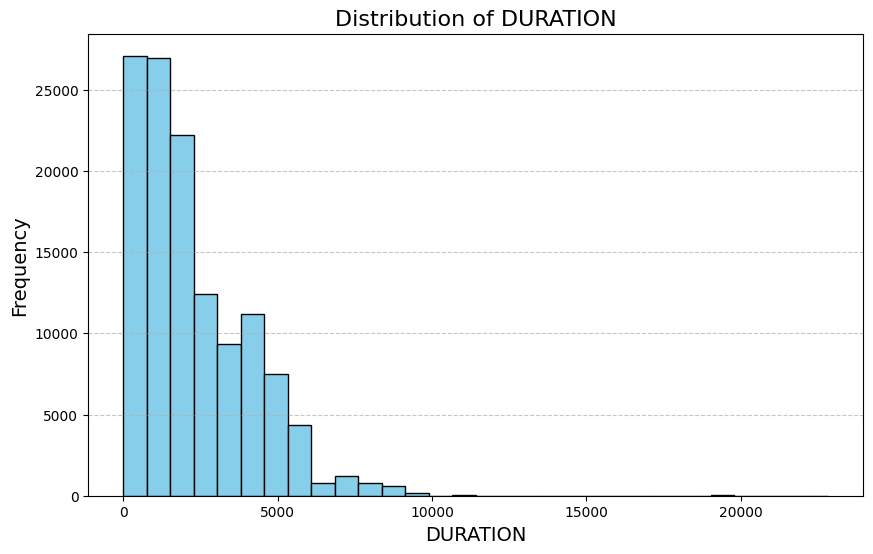

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df_processed['DURATION'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of DURATION', fontsize=16)
plt.xlabel('DURATION', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [13]:
df_processed.shape

(124710, 27)

In [14]:
Q1 = df_processed['DURATION'].quantile(0.25)
Q3 = df_processed['DURATION'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_processed = df_processed[
    (df_processed['DURATION'] >= lower_bound)
    & (df_processed['DURATION'] <= upper_bound)
].copy()



In [15]:
df_processed.DURATION.describe()

count    122024.000000
mean       2161.183505
std        1601.465231
min           2.000000
25%         853.000000
50%        1734.000000
75%        3287.000000
max        7344.000000
Name: DURATION, dtype: float64

In [16]:

dfv_full = df_processed.copy()
dfv_full = dfv_full[dfv_full['DURATION'] > 0].copy()

# Separate events and censored
dfv_events   = dfv_full[dfv_full['num__Event'] == 1]
dfv_censored = dfv_full[dfv_full['num__Event'] == 0]

print("Events   :", len(dfv_events))
print("Censored :", len(dfv_censored))
print("Total    :", len(dfv_full))

Events   : 531
Censored : 121493
Total    : 122024


In [17]:
df_processed.loc[df_processed['num__Event'] == 1].shape

(531, 27)

MODEL

In [18]:
# Build model matrices
# Important: the original tuned notebook trained on num__DURATION.
# We keep that behavior here so the final notebook matches the tuned run.

dfv = df_processed.copy()
dfv = dfv[dfv['num__DURATION'].notna()].copy()
dfv = dfv[dfv['num__DURATION'] > 0].copy()
dfv = dfv[dfv['num__Event'].notna()].copy()

T = dfv['num__DURATION'].to_numpy(np.float32)
E = dfv['num__Event'].astype(int).to_numpy(np.int32)

drop_cols = [
    'num__DURATION',
    'num__Event',
    'date__FRACTURE_TIMESTAMP',
    'date__LAYING_DATE',
    'date__USFDTIMESTAMP',
]

X_df = dfv.drop(columns=drop_cols, errors='ignore')
X = X_df.to_numpy(np.float32)

X_train, X_test, y_time_tr, y_time_te, y_event_tr, y_event_te = train_test_split(
    X,
    T,
    E,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=E,
)

valid_tr = (~np.isnan(y_time_tr)) & (y_time_tr > 0)
valid_te = (~np.isnan(y_time_te)) & (y_time_te > 0)

X_train = X_train[valid_tr]
y_time_tr = y_time_tr[valid_tr]
y_event_tr = y_event_tr[valid_tr]

X_test = X_test[valid_te]
y_time_te = y_time_te[valid_te]
y_event_te = y_event_te[valid_te]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train).astype(np.float32)
X_test_s = scaler.transform(X_test).astype(np.float32)

print('Train shape:', X_train_s.shape)
print('Test shape:', X_test_s.shape)
print('Train events:', int(y_event_tr.sum()))
print('Test events:', int(y_event_te.sum()))


Train shape: (424, 22)
Test shape: (107, 22)
Train events: 424
Test events: 107


In [19]:
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.global_start = time.time()
        print("\nTraining started...\n")

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start
        total_time = time.time() - self.global_start
        loss = logs.get('loss', float('nan'))
        val_loss = logs.get('val_loss', float('nan'))
        print(
            f"Epoch {epoch + 1:03d} | "
            f"loss={loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"epoch_time={epoch_time:.2f}s | "
            f"total_time={total_time / 60:.2f} min"
        )

    def on_train_end(self, logs=None):
        total_time = time.time() - self.global_start
        print(f"\nTraining finished in {total_time / 60:.2f} minutes.\n")


def prior_fn(dtype, shape, name, trainable, add_variable_fn):
    del name, trainable, add_variable_fn
    return tfd.Independent(
        tfd.Normal(
            loc=tf.zeros(shape, dtype=dtype),
            scale=tf.ones(shape, dtype=dtype),
        ),
        reinterpreted_batch_ndims=len(shape),
    )


posterior_fn = tfp.layers.default_mean_field_normal_fn(
    is_singular=False,
    loc_initializer=keras.initializers.Zeros(),
    untransformed_scale_initializer=keras.initializers.Constant(-2.2),
)


def kl_sum(q, p, _):
    return 1e-5 * tf.reduce_sum(tfp.distributions.kl_divergence(q, p))


def build_bnn(input_dim: int):
    inputs = keras.Input(shape=(int(input_dim),), dtype='float32', name='x')
    x = tfp.layers.DenseReparameterization(
        64,
        activation='relu',
        kernel_prior_fn=prior_fn,
        kernel_posterior_fn=posterior_fn,
        kernel_divergence_fn=kl_sum,
        bias_divergence_fn=kl_sum,
    )(inputs)
    x = tfp.layers.DenseReparameterization(
        32,
        activation='relu',
        kernel_prior_fn=prior_fn,
        kernel_posterior_fn=posterior_fn,
        kernel_divergence_fn=kl_sum,
        bias_divergence_fn=kl_sum,
    )(x)
    outputs = tfp.layers.DenseReparameterization(
        1,
        activation=None,
        kernel_prior_fn=prior_fn,
        kernel_posterior_fn=posterior_fn,
        kernel_divergence_fn=kl_sum,
        bias_divergence_fn=kl_sum,
    )(x)
    return keras.Model(inputs, outputs, name='BNN_gX')


@tf.function
def neg_log_partial_lik(y_true, y_pred):
    event = tf.cast(y_true[:, 0], tf.float32)
    time = tf.cast(y_true[:, 1], tf.float32)
    risk = tf.cast(tf.squeeze(y_pred, axis=-1), tf.float32)

    order = tf.argsort(time, direction='DESCENDING')
    time = tf.gather(time, order)
    event = tf.gather(event, order)
    risk = tf.gather(risk, order)

    lse_prefix = tf.math.cumulative_logsumexp(risk)

    is_new = tf.concat([[True], tf.not_equal(time[1:], time[:-1])], axis=0)
    gid = tf.cumsum(tf.cast(is_new, tf.int32)) - 1

    is_end = tf.concat([tf.not_equal(time[:-1], time[1:]), [True]], axis=0)
    end_lse = tf.boolean_mask(lse_prefix, is_end)
    denom = tf.gather(end_lse, gid)

    loglik = tf.reduce_sum(event * (risk - denom))
    return -loglik / (tf.reduce_sum(event) + 1e-8)


def train_bnn_and_get_g(X_tr, time_tr, event_tr, X_te, lr=BEST_LR, epochs=EPOCHS):
    model = build_bnn(X_tr.shape[1])
    model.compile(optimizer=keras.optimizers.RMSprop(lr), loss=neg_log_partial_lik)

    y_tr = np.column_stack([event_tr, time_tr]).astype(np.float32)

    es = keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True)
    timer = EpochTimer()

    model.fit(
        X_tr.astype(np.float32),
        y_tr,
        batch_size=X_tr.shape[0],
        epochs=epochs,
        verbose=0,
        validation_split=0.2,
        shuffle=False,
        callbacks=[es, timer],
    )

    g_tr = model.predict(X_tr.astype(np.float32), verbose=0).reshape(-1)
    g_te = model.predict(X_te.astype(np.float32), verbose=0).reshape(-1)
    return g_tr, g_te


def find_col(name_substr, colnames):
    hits = [i for i, col in enumerate(colnames) if name_substr in col]
    if len(hits) != 1:
        raise ValueError(
            f"Expected 1 match for {name_substr}, got {len(hits)}: {[colnames[i] for i in hits[:10]]}"
        )
    return hits[0]


In [20]:
print(f"Running final model with best learning rate: {BEST_LR}")

g_tr_final, g_te_final = train_bnn_and_get_g(
    X_train_s,
    y_time_tr,
    y_event_tr,
    X_test_s,
    lr=BEST_LR,
    epochs=EPOCHS,
)

colnames = list(X_df.columns)
i_axle = find_col('AXLELOAD', colnames)
i_gmt = find_col('GMTCARRIED', colnames)
i_annual = find_col('ANNUAL_GMT', colnames)
i_rail = find_col('RAIL_SECTION', colnames)
i_service = find_col('SERVICE_LIFE', colnames)
i_speed = find_col('SPEED', colnames)
i_track_lwr = find_col('TRACK_TYPE_LWR', colnames)
i_track_swr = find_col('TRACK_TYPE_SWR', colnames)
i_straight = find_col('STRAIGHT_CURVE_STRAIGHT', colnames)

X_lin_tr = X_train[:, [i_axle, i_gmt, i_annual, i_rail, i_service, i_speed, i_track_lwr, i_track_swr, i_straight]]
X_lin_te = X_test[:, [i_axle, i_gmt, i_annual, i_rail, i_service, i_speed, i_track_lwr, i_track_swr, i_straight]]

train_df_final = pd.DataFrame({
    'time': y_time_tr,
    'event': y_event_tr,
    'AXLE_LOAD': X_lin_tr[:, 0],
    'GMT_CARRIED': X_lin_tr[:, 1],
    'ANNUAL_GMT': X_lin_tr[:, 2],
    'RAIL_SECTION': X_lin_tr[:, 3],
    'SERVICE_LIFE': X_lin_tr[:, 4],
    'SPEED': X_lin_tr[:, 5],
    'TRACK_TYPE_LWR': X_lin_tr[:, 6],
    'TRACK_TYPE_SWR': X_lin_tr[:, 7],
    'STRAIGHT_CURVE_STRAIGHT': X_lin_tr[:, 8],
    'g_bnn': g_tr_final,
})

test_df_final = pd.DataFrame({
    'time': y_time_te,
    'event': y_event_te,
    'AXLE_LOAD': X_lin_te[:, 0],
    'GMT_CARRIED': X_lin_te[:, 1],
    'ANNUAL_GMT': X_lin_te[:, 2],
    'RAIL_SECTION': X_lin_te[:, 3],
    'SERVICE_LIFE': X_lin_te[:, 4],
    'SPEED': X_lin_te[:, 5],
    'TRACK_TYPE_LWR': X_lin_te[:, 6],
    'TRACK_TYPE_SWR': X_lin_te[:, 7],
    'STRAIGHT_CURVE_STRAIGHT': X_lin_te[:, 8],
    'g_bnn': g_te_final,
})
train_df_final['SECTION_FREQ'] = X_train[:, find_col('SECTION_FREQ', colnames)]
test_df_final['SECTION_FREQ'] = X_test[:, find_col('SECTION_FREQ', colnames)]


'''formula = """
AXLE_LOAD + GMT_CARRIED + ANNUAL_GMT + RAIL_SECTION +
SERVICE_LIFE + SPEED + TRACK_TYPE_LWR + TRACK_TYPE_SWR +
STRAIGHT_CURVE_STRAIGHT + g_bnn + SECTION_FREQ
"""'''

formula = """
AXLE_LOAD + GMT_CARRIED + ANNUAL_GMT + RAIL_SECTION + g_bnn
"""

'''formula = """SERVICE_LIFE + GMT_CARRIED + SPEED + TRACK_TYPE_LWR + TRACK_TYPE_SWR + STRAIGHT_CURVE_STRAIGHT + g_bnn"""'''

'''formula = """
ANNUAL_GMT + SPEED + TRACK_TYPE_LWR + TRACK_TYPE_SWR + STRAIGHT_CURVE_STRAIGHT + g_bnn
"""'''

'''formula = """
AXLE_LOAD + ANNUAL_GMT + RAIL_SECTION + SERVICE_LIFE + GMT_CARRIED + SPEED + TRACK_TYPE_LWR + TRACK_TYPE_SWR + STRAIGHT_CURVE_STRAIGHT
 + g_bnn
"""'''

cph_final = CoxPHFitter()
cph_final.fit(train_df_final, duration_col='time', event_col='event', formula=formula)

print(cph_final.params_)

risk_tr_final = cph_final.predict_partial_hazard(train_df_final).values.ravel()
risk_te_final = cph_final.predict_partial_hazard(test_df_final).values.ravel()

c_tr_final = concordance_index(train_df_final['time'].values, -risk_tr_final, train_df_final['event'].values)
c_te_final = concordance_index(test_df_final['time'].values, -risk_te_final, test_df_final['event'].values)

print(f"C-index (final model) train={c_tr_final:.3f}  test={c_te_final:.3f}")


Running final model with best learning rate: 0.01



c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow_probability\python\layers\util.py:99: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow_probability\python\layers\util.py:109: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tf_keras\src\initializers\initializers.py:121: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(



Training started...


Epoch 001 | loss=4.9115 | val_loss=3.5602 | epoch_time=2.63s | total_time=0.05 min
Epoch 002 | loss=4.8926 | val_loss=3.5026 | epoch_time=0.05s | total_time=0.05 min
Epoch 003 | loss=4.9102 | val_loss=3.5678 | epoch_time=0.04s | total_time=0.05 min
Epoch 004 | loss=4.9060 | val_loss=3.5063 | epoch_time=0.05s | total_time=0.05 min
Epoch 005 | loss=4.8687 | val_loss=3.4803 | epoch_time=0.06s | total_time=0.05 min
Epoch 006 | loss=4.8845 | val_loss=3.4311 | epoch_time=0.06s | total_time=0.05 min
Epoch 007 | loss=4.8164 | val_loss=3.4315 | epoch_time=0.06s | total_time=0.05 min
Epoch 008 | loss=4.7534 | val_loss=3.3127 | epoch_time=0.06s | total_time=0.05 min
Epoch 009 | loss=4.7035 | val_loss=3.2391 | epoch_time=0.06s | total_time=0.05 min
Epoch 010 | loss=4.6849 | val_loss=3.2308 | epoch_time=0.05s | total_time=0.05 min
Epoch 011 | loss=4.5246 | val_loss=3.2034 | epoch_time=0.05s | total_time=0.06 min
Epoch 012 | loss=4.3868 | val_loss=3.1424 | epoch_time=0.05s | t

In [21]:
# C-index for train and test

model = cph_final if 'cph_final' in globals() else cph
train_data = train_df_final if 'train_df_final' in globals() else train_df
test_data = test_df_final if 'test_df_final' in globals() else test_df

risk_tr = model.predict_partial_hazard(train_data).values.ravel()
risk_te = model.predict_partial_hazard(test_data).values.ravel()

c_tr = concordance_index(
    train_data["time"].values,
    -risk_tr,
    train_data["event"].values
)

c_te = concordance_index(
    test_data["time"].values,
    -risk_te,
    test_data["event"].values
)

print(f"Train C-index: {c_tr:.4f}")
print(f"Test C-index:  {c_te:.4f}")


Train C-index: 0.9278
Test C-index:  0.9328


In [22]:
# RMSE using predicted median survival time on event rows only

t_min = float(np.min(y_time_te))
t_max = float(np.max(y_time_te))
eps = np.nextafter(t_max, -np.inf)
times = np.linspace(t_min, eps, 200)

surv_df_final = cph_final.predict_survival_function(test_df_final, times=times)
S_final = surv_df_final.to_numpy().T


def median_time_from_curve(times_grid, survival_row):
    idx = np.where(survival_row <= 0.5)[0]
    return times_grid[idx[0]] if len(idx) else times_grid[-1]


t50_pred_final = np.array(
    [median_time_from_curve(times, s_row) for s_row in S_final],
    dtype=float,
)
mask_event_final = y_event_te == 1
rmse_t50_final = np.sqrt(
    np.mean((t50_pred_final[mask_event_final] - y_time_te[mask_event_final]) ** 2)
)

print(f"RMSE (median survival time, events only): {rmse_t50_final:.3f}")
print(f"Num events used: {int(mask_event_final.sum())}")


RMSE (median survival time, events only): 318.835
Num events used: 107


In [23]:
# Integrated Brier Score (IBS)

y_train_struct_final = Surv.from_arrays(y_event_tr.astype(bool), y_time_tr.astype(float))
y_test_struct_final = Surv.from_arrays(y_event_te.astype(bool), y_time_te.astype(float))

t_min = float(np.min(y_time_te))
t_max = float(np.max(y_time_te))
eps = np.nextafter(t_max, -np.inf)
times_ibs_final = np.linspace(t_min, eps, 200)

surv_df_ibs_final = cph_final.predict_survival_function(test_df_final, times=times_ibs_final)
S_pred_ibs_final = surv_df_ibs_final.to_numpy().T

ibs_final = integrated_brier_score(
    y_train_struct_final,
    y_test_struct_final,
    S_pred_ibs_final,
    times_ibs_final,
)

print(f"IBS (final model): {ibs_final:.3f}")


IBS (final model): 0.026


In [24]:
import pickle

# Save the CoxPHFitter model
with open(BASE_DIR / "cph_NCR.pkl", "wb") as f:
    pickle.dump(cph_final, f)

# Save the scaler
with open(BASE_DIR / "scaler_NCR.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Retrain the BNN model so we can save it
model_NCR = build_bnn(X_train_s.shape[1])
model_NCR.compile(optimizer=keras.optimizers.RMSprop(learning_rate=BEST_LR), loss=neg_log_partial_lik)

y_tr = np.column_stack([y_event_tr, y_time_tr]).astype(np.float32)

es = keras.callbacks.EarlyStopping(patience=PATIENCE, restore_best_weights=True)
timer = EpochTimer()

model_NCR.fit(
    X_train_s,
    y_tr,
    batch_size=X_train_s.shape[0],
    epochs=EPOCHS,
    verbose=0,
    validation_split=0.2,
    shuffle=False,
    callbacks=[es, timer],
)

model_NCR.save(BASE_DIR / "bnn_model_NCR.pkl", save_format="h5")

print("Saved cph_NCR.pkl")
print("Saved scaler_NCR.pkl")
print("Saved bnn_model_NCR.pkl")

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow_probability\python\layers\util.py:99: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow_probability\python\layers\util.py:109: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(
c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tf_keras\src\initializers\initializers.py:121: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than on


Training started...

Epoch 001 | loss=4.8956 | val_loss=3.5750 | epoch_time=2.01s | total_time=0.03 min
Epoch 002 | loss=4.8754 | val_loss=3.6053 | epoch_time=0.04s | total_time=0.03 min
Epoch 003 | loss=4.9844 | val_loss=3.5232 | epoch_time=0.06s | total_time=0.04 min
Epoch 004 | loss=4.8827 | val_loss=3.4558 | epoch_time=0.05s | total_time=0.04 min
Epoch 005 | loss=4.8657 | val_loss=3.5330 | epoch_time=0.04s | total_time=0.04 min
Epoch 006 | loss=4.7954 | val_loss=3.4393 | epoch_time=0.06s | total_time=0.04 min
Epoch 007 | loss=4.7945 | val_loss=3.4419 | epoch_time=0.04s | total_time=0.04 min
Epoch 008 | loss=4.6945 | val_loss=3.4097 | epoch_time=0.06s | total_time=0.04 min
Epoch 009 | loss=4.7007 | val_loss=3.3011 | epoch_time=0.05s | total_time=0.04 min
Epoch 010 | loss=4.5605 | val_loss=3.1857 | epoch_time=0.05s | total_time=0.04 min
Epoch 011 | loss=4.6261 | val_loss=3.2292 | epoch_time=0.04s | total_time=0.04 min
Epoch 012 | loss=4.5083 | val_loss=3.1092 | epoch_time=0.05s | to

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tf_keras\src\engine\training.py:3098: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


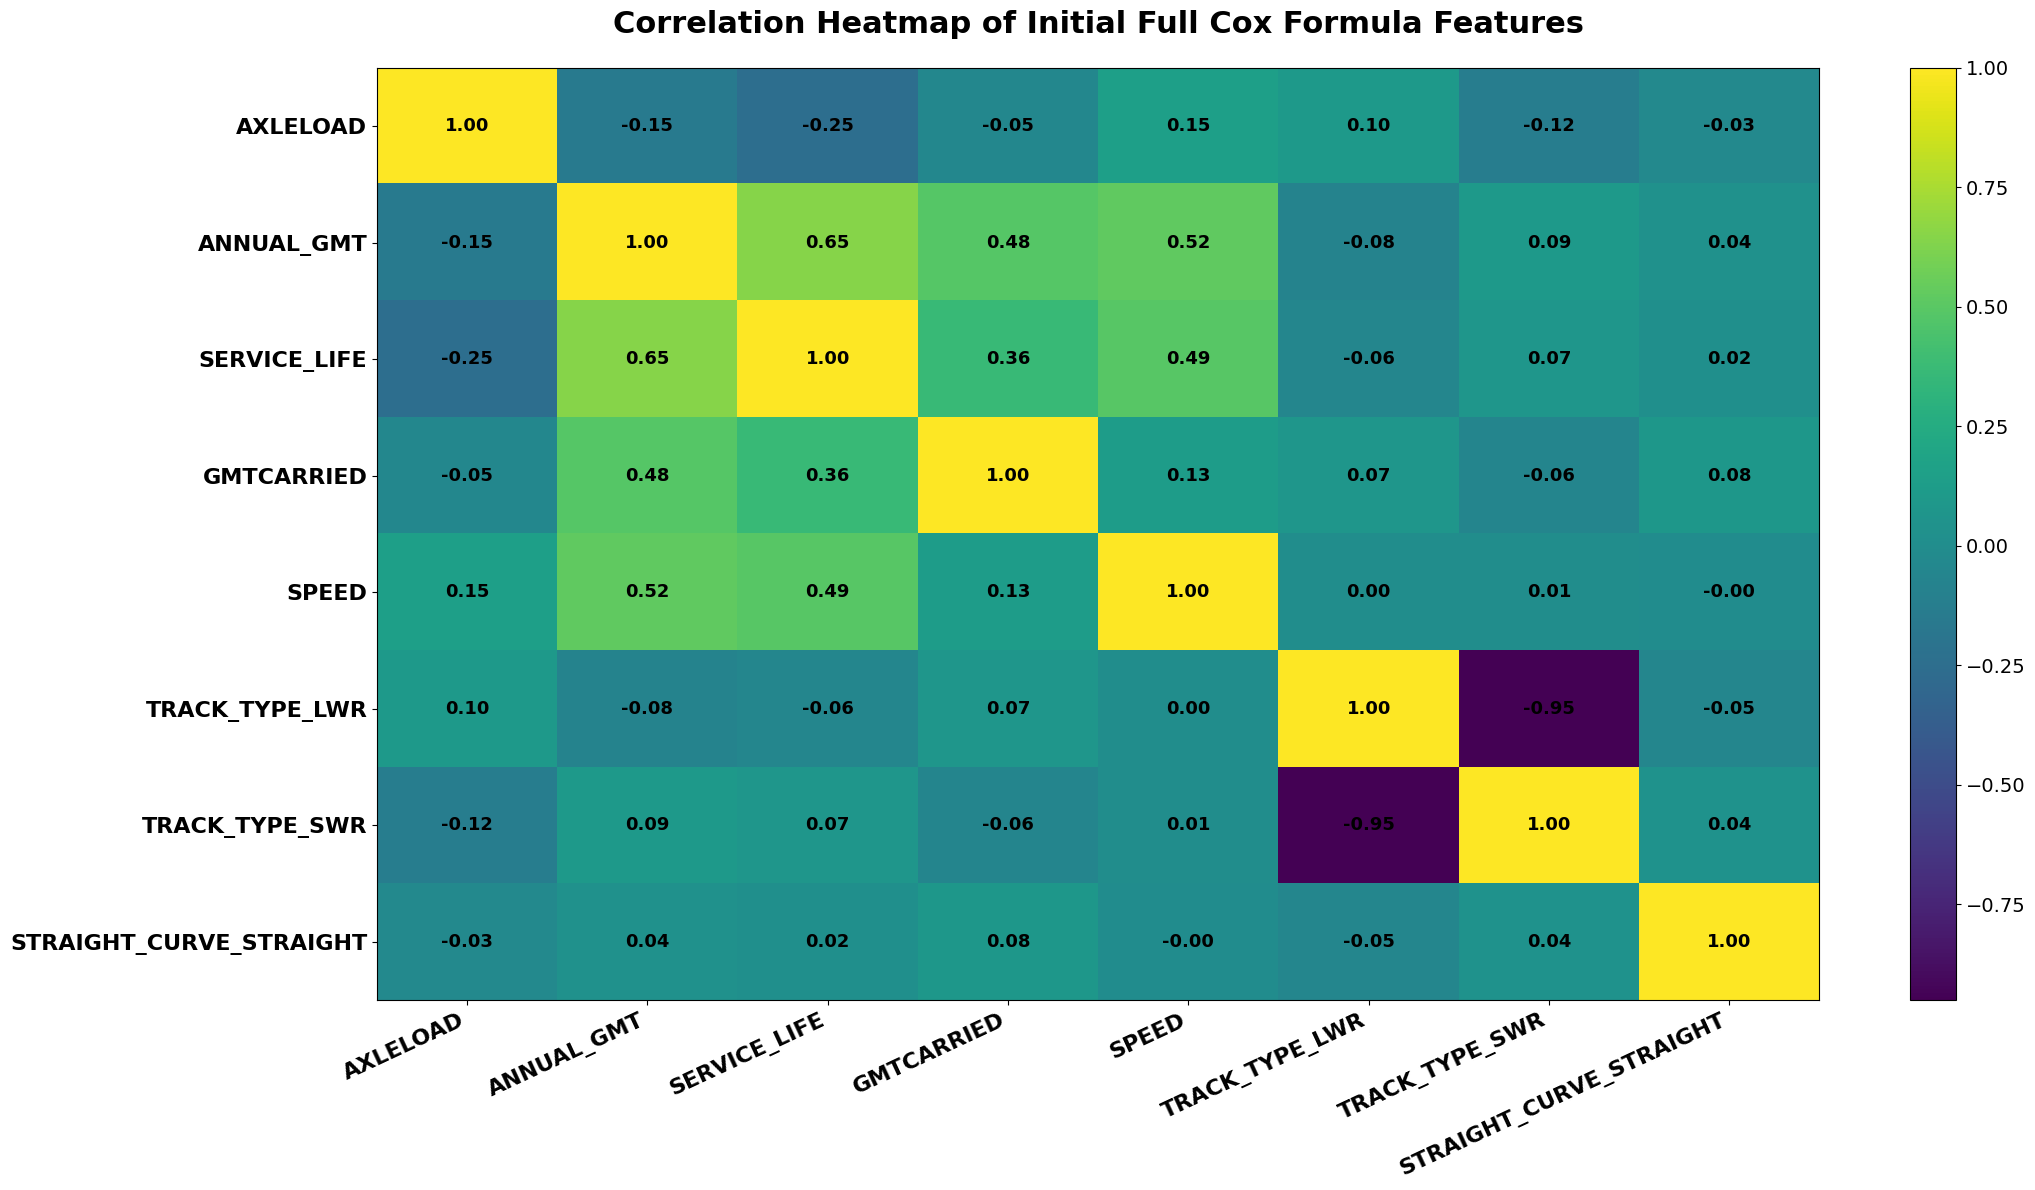

In [25]:
# ==========================================================
# LARGE & READABLE CORRELATION HEATMAP
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# COPY DATA
# ----------------------------------------------------------

df_corr = final_df.copy()

# ----------------------------------------------------------
# CREATE DUMMY VARIABLES
# ----------------------------------------------------------

df_corr = pd.get_dummies(
    df_corr,
    columns=[
        'TRACK_TYPE',
        'STRAIGHT_CURVE'
    ],
    drop_first=False
)

# ----------------------------------------------------------
# SELECT FEATURES
# ----------------------------------------------------------

features = [
    'AXLELOAD',
    'ANNUAL_GMT',
    'SERVICE_LIFE',
    'GMTCARRIED',
    'SPEED',
    'TRACK_TYPE_LWR',
    'TRACK_TYPE_SWR',
    'STRAIGHT_CURVE_STRAIGHT'
]

if 'g_bnn' in df_corr.columns:
    features.append('g_bnn')

features = [f for f in features if f in df_corr.columns]

# ----------------------------------------------------------
# PREPARE DATA
# ----------------------------------------------------------

corr_df = df_corr[features].copy()

corr_df = corr_df.replace([np.inf, -np.inf], np.nan).dropna()

corr_df = corr_df.astype(float)

# ----------------------------------------------------------
# CORRELATION MATRIX
# ----------------------------------------------------------

corr_matrix = corr_df.corr()

# ----------------------------------------------------------
# EXTRA LARGE HEATMAP
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(22, 12))

im = ax.imshow(
    corr_matrix,
    aspect='auto'
)

# ----------------------------------------------------------
# LARGE LABELS
# ----------------------------------------------------------

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(
    corr_matrix.columns,
    rotation=25,
    ha='right',
    fontsize=16,
    fontweight='bold'
)

ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(
    corr_matrix.columns,
    fontsize=16,
    fontweight='bold'
)

# ----------------------------------------------------------
# LARGE CORRELATION VALUES
# ----------------------------------------------------------

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):

        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center',
            fontsize=13,
            fontweight='bold',
            color='black'
        )

# ----------------------------------------------------------
# COLORBAR
# ----------------------------------------------------------

cbar = plt.colorbar(im)

cbar.ax.tick_params(labelsize=14)

# ----------------------------------------------------------
# TITLE
# ----------------------------------------------------------

plt.title(
    "Correlation Heatmap of Initial Full Cox Formula Features",
    fontsize=22,
    fontweight='bold',
    pad=25
)

plt.tight_layout()

plt.show()

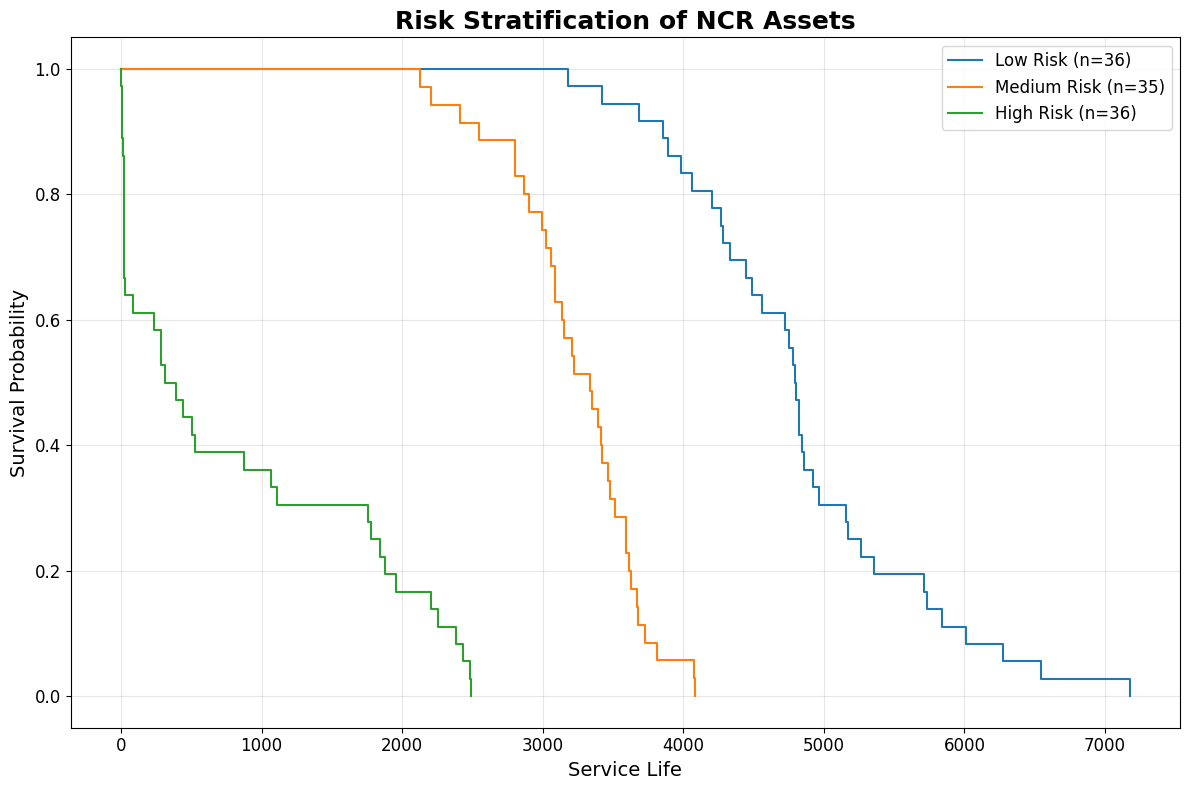

Risk_Group
Low Risk       36
High Risk      36
Medium Risk    35
Name: count, dtype: int64


In [26]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================================
# Risk Score
# ==========================================================

risk_df = test_df_final.copy()

risk_df["risk_score"] = np.asarray(
    cph_final.predict_partial_hazard(test_df_final)
).flatten()

# ==========================================================
# Low / Medium / High Risk Groups
# ==========================================================

risk_df["Risk_Group"] = pd.qcut(
    risk_df["risk_score"],
    q=3,
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

# ==========================================================
# Kaplan-Meier Plot
# ==========================================================

plt.figure(figsize=(12,8))

kmf = KaplanMeierFitter()

for group in ["Low Risk", "Medium Risk", "High Risk"]:

    mask = risk_df["Risk_Group"] == group

    kmf.fit(
        durations=risk_df.loc[mask, "time"],
        event_observed=risk_df.loc[mask, "event"],
        label=f"{group} (n={mask.sum()})"
    )

    kmf.plot_survival_function(ci_show=False)

plt.title(
    "Risk Stratification of NCR Assets",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Service Life", fontsize=14)
plt.ylabel("Survival Probability", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================================
# Check Group Sizes
# ==========================================================

print(risk_df["Risk_Group"].value_counts())

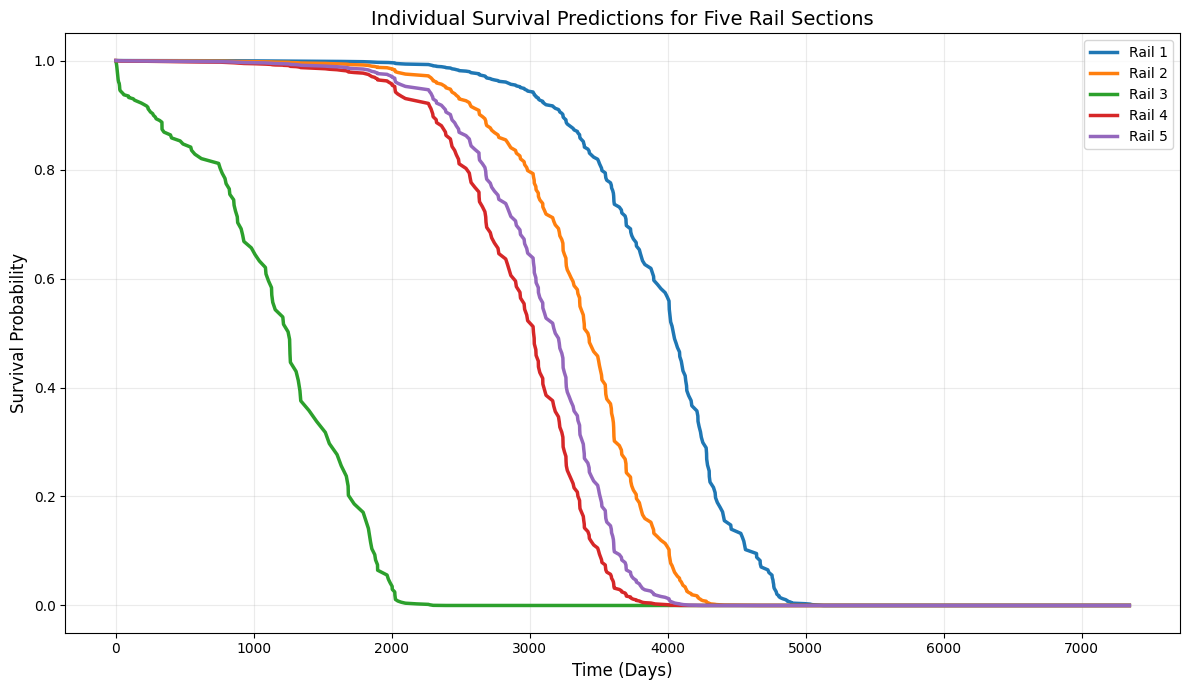

In [27]:
sample_idx = [20,40, 60, 80, 100,]

samples = test_df_final.iloc[sample_idx]

surv_funcs = cph_final.predict_survival_function(samples)

plt.figure(figsize=(12,7))

for i, col in enumerate(surv_funcs.columns):
    plt.plot(
        surv_funcs.index,
        surv_funcs[col],
        lw=2.5,
        label=f"Rail {i+1}"
    )

plt.xlabel("Time (Days)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.title("Individual Survival Predictions for Five Rail Sections", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [28]:
# ==========================================================
# Classification Metrics (Styled Terminal Output)
# ==========================================================

from sklearn.metrics import (
    roc_curve, f1_score, accuracy_score, precision_score, recall_score
)
import numpy as np

# --- Convert survival risk scores to binary labels for classification ---
# Using the Cox model risk scores on the test set
risk_scores = cph_final.predict_partial_hazard(test_df_final).values.ravel()
y_true = test_df_final["event"].values.astype(int)

# --- Find best threshold via F1 ---
fpr, tpr, thresholds = roc_curve(y_true, risk_scores)
sensitivity_arr = tpr
specificity_arr = 1 - fpr

f1_scores = []
for thresh in thresholds:
    preds = (risk_scores >= thresh).astype(int)
    f1_scores.append(f1_score(y_true, preds, zero_division=0))
f1_scores = np.array(f1_scores)

best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1        = f1_scores[best_idx]
best_sens      = sensitivity_arr[best_idx]
best_spec      = specificity_arr[best_idx]

y_pred = (risk_scores >= best_threshold).astype(int)
acc   = accuracy_score(y_true, y_pred)
prec  = precision_score(y_true, y_pred, zero_division=0)
rec   = recall_score(y_true, y_pred, zero_division=0)

# --- Styled terminal-style print ---
bar = "#" * 42
print(bar)
print(f"  Sensitivity:      {best_sens:.4f}")
print(f"  Specificity:      {best_spec:.4f}")
print(bar)
print(f"  Best threshold:   {best_threshold:.6f}")
print(f"  Best F1:          {best_f1:.4f}")
print(bar)
print(f"  Accuracy  :       {acc:.4f}")
print(f"  Precision :       {prec:.4f}")
print(f"  Recall    :       {rec:.4f}")
print(bar)


##########################################
  Sensitivity:      1.0000
  Specificity:      nan
##########################################
  Best threshold:   0.000128
  Best F1:          1.0000
##########################################
  Accuracy  :       1.0000
  Precision :       1.0000
  Recall    :       1.0000
##########################################


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


In [29]:
T_test_full = dfv['num__DURATION'].to_numpy(np.float32)
E_test_full = dfv['num__Event'].astype(int).to_numpy(np.int32)

In [30]:


dfv = df_processed.copy()

# Use DURATION (recomputed in Cell 9 for ALL subjects including censored)
# num__DURATION only exists for fractured rails â†’ drops all censored
dfv = dfv[dfv['DURATION'].notna()].copy()
dfv = dfv[dfv['DURATION'] > 0].copy()
dfv = dfv[dfv['num__Event'].notna()].copy()

print("After filter:")
print("  Total    :", len(dfv))
print("  Events   :", (dfv['num__Event'] == 1).sum())
print("  Censored :", (dfv['num__Event'] == 0).sum())

T = dfv['num__DURATION'].to_numpy(np.float32)          # â† DURATION not num__DURATION
E = dfv['num__Event'].astype(int).to_numpy(np.int32)

drop_cols = [
    'num__DURATION',
    'num__Event',
    'DURATION',
    'CENSOR_DATE',
    'date__FRACTURE_TIMESTAMP',
    'date__LAYING_DATE',
    'date__USFDTIMESTAMP',
]

X_df = dfv.drop(columns=drop_cols, errors='ignore')
X    = X_df.to_numpy(np.float32)

X_train, X_test, y_time_tr, y_time_te, y_event_tr, y_event_te = train_test_split(
    X, T, E,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = E,
)

# No NaN filter needed â€” DURATION is fully populated for all subjects
# but keep as safety check
valid_tr = (y_time_tr > 0)
valid_te = (y_time_te > 0)

X_train    = X_train[valid_tr];    y_time_tr  = y_time_tr[valid_tr];  y_event_tr = y_event_tr[valid_tr]
X_test     = X_test[valid_te];     y_time_te  = y_time_te[valid_te];  y_event_te = y_event_te[valid_te]

scaler     = StandardScaler()
X_train_s  = scaler.fit_transform(X_train).astype(np.float32)
X_test_s   = scaler.transform(X_test).astype(np.float32)

# Store column names for downstream use
colnames   = list(X_df.columns)

print("\nAfter split:")
print("  Train shape :", X_train_s.shape)
print("  Test shape  :", X_test_s.shape)
print("  Train events:", int(y_event_tr.sum()), " | censored:", int((y_event_tr==0).sum()))
print("  Test events :", int(y_event_te.sum()), " | censored:", int((y_event_te==0).sum()))

After filter:
  Total    : 122024
  Events   : 531
  Censored : 121493

After split:
  Train shape : (425, 20)
  Test shape  : (106, 20)
  Train events: 425  | censored: 0
  Test events : 106  | censored: 0


Fracture time percentiles (days):
   10th pct :     43.0 days  (0.1 years)
   25th pct :   1065.2 days  (2.9 years)
   33th pct :   1984.5 days  (5.4 years)
   50th pct :   2896.0 days  (7.9 years)
   67th pct :   3660.6 days  (10.0 years)
   75th pct :   4050.2 days  (11.1 years)
   90th pct :   5195.5 days  (14.2 years)


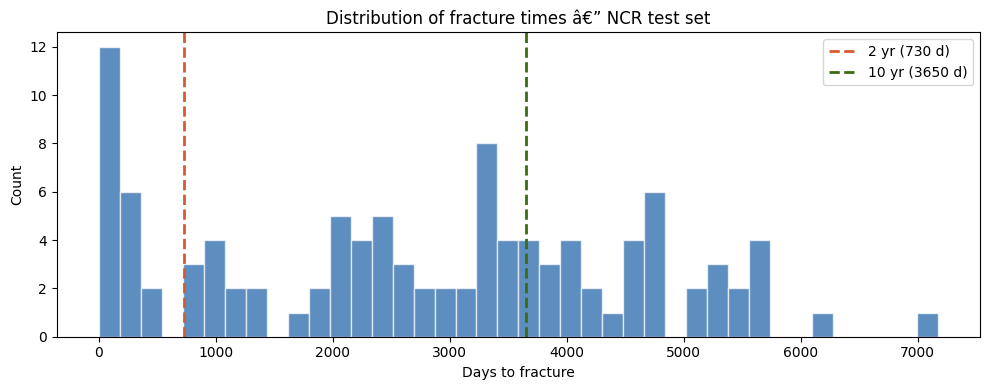

In [31]:
import matplotlib.pyplot as plt
import numpy as np

fractured = y_time_te[y_event_te == 1]

percentiles = [10, 25, 33, 50, 67, 75, 90]
print("Fracture time percentiles (days):")
for p in percentiles:
    val = np.percentile(fractured, p)
    print(f"  {p:3d}th pct : {val:8.1f} days  ({val/365:.1f} years)")

plt.figure(figsize=(10, 4))
plt.hist(fractured, bins=40, color='#185FA5', alpha=0.7, edgecolor='white')
plt.axvline(730,  color='#D85A30', lw=2, linestyle='--', label='2 yr (730 d)')
plt.axvline(3650, color='#3B6D11', lw=2, linestyle='--', label='10 yr (3650 d)')
plt.xlabel("Days to fracture")
plt.ylabel("Count")
plt.title("Distribution of fracture times â€” NCR test set")
plt.legend()
plt.tight_layout()
plt.show()

Test set: 107 rails  |  Fractured: 107  |  Censored: 0

Fixed-horizon risk scores by status
          risk_5_4yr                                                  risk_10yr                                                 
               count    mean     std  min     25%     50%    75%  max     count    mean     std     min    25%     50%  75%  max
status                                                                                                                          
Fractured      107.0  0.2983  0.4215  0.0  0.0038  0.0174  0.707  1.0     107.0  0.6512  0.3789  0.0009  0.281  0.7823  1.0  1.0

Event-time risk is shown only for fractured rails; censored event time is unknown.


,observed_days,observed_years,event,status,partial_hazard,risk_at_event,risk_5_4yr,risk_10yr
0,1066.000000,2.92,1,Fractured,49.1512,0.4384,0.9786,1.0000
1,1111.000000,3.04,1,Fractured,60.7316,0.5473,0.9914,1.0000
2,440.000000,1.21,1,Fractured,200.2254,0.5438,1.0000,1.0000
3,1876.000000,5.14,1,Fractured,16.9669,0.6336,0.7348,1.0000
4,9.000000,0.02,1,Fractured,511.1663,0.1561,1.0000,1.0000
5,28.000000,0.08,1,Fractured,900.9768,0.6570,1.0000,1.0000
6,529.000000,1.45,1,Fractured,213.1718,0.5985,1.0000,1.0000
7,24.000000,0.07,1,Fractured,429.5666,0.3618,1.0000,1.0000
8,2206.000000,6.04,1,Fractured,6.4594,0.6172,0.3967,1.0000
9,2486.000000,6.81,1,Fractured,8.1246,0.9574,0.4704,1.0000


ValueError: zero-size array to reduction operation minimum which has no identity

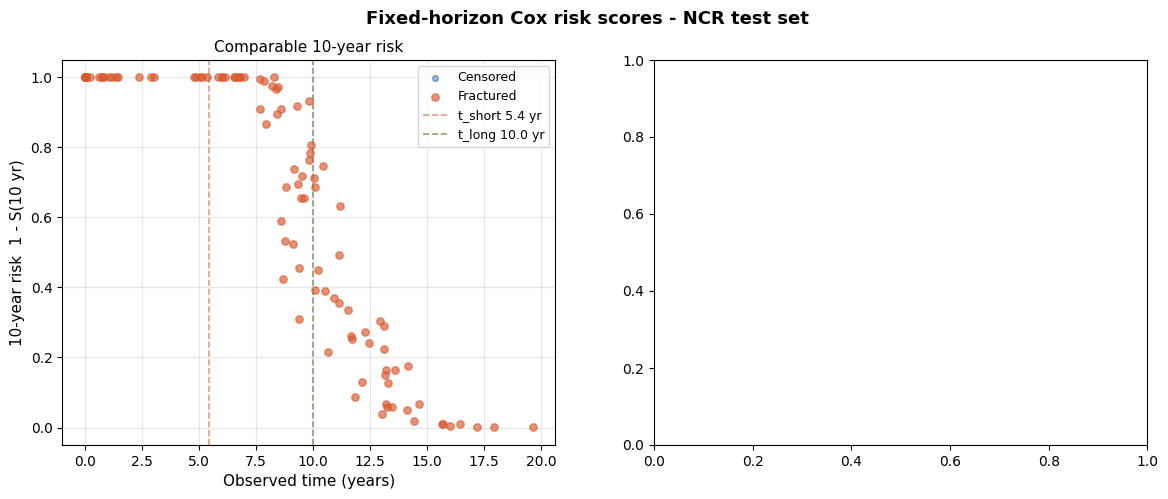

In [ ]:
# ================================================================
# CELL: Comparable risk scores at fixed horizons for each rail
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Use comparable fixed-time risks, not each rail's own censoring time.
# A censored rail did not fail at its censoring date, so 1-S(censor_time)
# is not a fair model risk score for comparing censored vs fractured rails.
obs_times = test_df_final["time"].to_numpy(dtype=float)
events = test_df_final["event"].to_numpy(dtype=int)
n = len(obs_times)
frac_mask = events == 1
cens_mask = events == 0

horizon_times = {
    "risk_5_4yr": 1984.0,
    "risk_10yr": 3660.0,
}
horizon_labels = list(horizon_times.keys())
horizon_values = np.array(list(horizon_times.values()), dtype=float)

# predict_survival_function returns rows=times, columns=subjects.
surv_horizon = cph_final.predict_survival_function(
    test_df_final, times=horizon_values
)

if surv_horizon.shape != (len(horizon_values), n):
    raise ValueError(
        f"Survival matrix shape {surv_horizon.shape} does not match "
        f"({len(horizon_values)}, {n})."
    )

risk_horizon = 1.0 - surv_horizon.to_numpy().T
partial_hazard = cph_final.predict_partial_hazard(test_df_final).to_numpy().ravel()

# Observed-time risk is meaningful only for actual fractured rails.
# For censored rails, the event time is unknown, so keep it as NaN.
risk_at_event = np.full(n, np.nan, dtype=float)
s_at_event = np.full(n, np.nan, dtype=float)
if frac_mask.any():
    event_times = np.unique(obs_times[frac_mask])
    surv_event = cph_final.predict_survival_function(
        test_df_final.loc[frac_mask], times=event_times
    )
    event_obs_times = obs_times[frac_mask]
    s_event = np.empty(frac_mask.sum(), dtype=float)
    for i, t in enumerate(event_obs_times):
        row_idx = np.searchsorted(event_times, t, side="left")
        row_idx = min(row_idx, len(event_times) - 1)
        s_event[i] = surv_event.iloc[row_idx, i]
    s_at_event[frac_mask] = s_event
    risk_at_event[frac_mask] = 1.0 - s_event

# 2. Build results table
df_risk = pd.DataFrame({
    "observed_days": obs_times,
    "observed_years": np.round(obs_times / 365, 2),
    "event": events,
    "status": np.where(events == 1, "Fractured", "Censored"),
    "partial_hazard": partial_hazard,
    "risk_at_event": risk_at_event,
})
for j, label in enumerate(horizon_labels):
    df_risk[label] = risk_horizon[:, j]

print(f"Test set: {n} rails  |  Fractured: {events.sum()}  |  Censored: {(events == 0).sum()}")
print("\nFixed-horizon risk scores by status")
print(df_risk.groupby("status")[horizon_labels].describe().round(4).to_string())
print("\nEvent-time risk is shown only for fractured rails; censored event time is unknown.")

display(
    df_risk.sort_values("risk_10yr", ascending=False)
           .head(20)
           .reset_index(drop=True)
           .style.background_gradient(subset=horizon_labels, cmap="RdYlGn_r")
                 .format({"partial_hazard": "{:.4f}", "risk_at_event": "{:.4f}",
                           "risk_5_4yr": "{:.4f}", "risk_10yr": "{:.4f}",
                           "observed_years": "{:.2f}"}, na_rep="")
)

# 3. Scatter: fixed risk vs observed time, coloured by status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fixed-horizon Cox risk scores - NCR test set",
             fontsize=13, fontweight="bold")

# Left: scatter of 10-year risk coloured by event type
ax = axes[0]
ax.scatter(obs_times[cens_mask] / 365, df_risk.loc[cens_mask, "risk_10yr"],
           color="#185FA5", alpha=0.45, s=18, label="Censored", zorder=2)
ax.scatter(obs_times[frac_mask] / 365, df_risk.loc[frac_mask, "risk_10yr"],
           color="#D85A30", alpha=0.65, s=28, label="Fractured", zorder=3)
ax.axvline(1984 / 365, color="#D85A30", lw=1.2, ls="--", alpha=0.6,
           label="t_short 5.4 yr")
ax.axvline(3660 / 365, color="#3B6D11", lw=1.2, ls="--", alpha=0.6,
           label="t_long 10.0 yr")
ax.set_xlabel("Observed time (years)", fontsize=11)
ax.set_ylabel("10-year risk  1 - S(10 yr)", fontsize=11)
ax.set_title("Comparable 10-year risk", fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Right: violin / strip comparison
ax2 = axes[1]
parts = ax2.violinplot(
    [df_risk.loc[cens_mask, "risk_10yr"], df_risk.loc[frac_mask, "risk_10yr"]],
    positions=[1, 2], showmedians=True, widths=0.6
)
for pc, col in zip(parts["bodies"], ["#185FA5", "#D85A30"]):
    pc.set_facecolor(col)
    pc.set_alpha(0.45)
for key in ["cmedians", "cbars", "cmaxes", "cmins"]:
    parts[key].set_color("#444")
    parts[key].set_linewidth(1)

# overlay jittered strips
rng = np.random.default_rng(42)
for pos, mask, col in [(1, cens_mask, "#185FA5"), (2, frac_mask, "#D85A30")]:
    jitter = rng.uniform(-0.12, 0.12, mask.sum())
    ax2.scatter(pos + jitter, df_risk.loc[mask, "risk_10yr"],
                color=col, alpha=0.35, s=12, zorder=3)

ax2.set_xticks([1, 2])
ax2.set_xticklabels(["Censored", "Fractured"], fontsize=11)
ax2.set_ylabel("10-year risk  1 - S(10 yr)", fontsize=11)
ax2.set_title("10-year risk distribution by status", fontsize=11)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

risk_5_4yr = df_risk["risk_5_4yr"].to_numpy()
risk_10yr = df_risk["risk_10yr"].to_numpy()
risk_at_obs = risk_10yr  # backward-compatible alias for downstream cells

print("\ndf_risk is available for further analysis.")

In [37]:
# ================================================================
# CELL: 3-class confusion matrix on risk_10yr scores
# Requires: risk_10yr, obs_times, events  (from previous cell)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import classification_report

T_SHORT = 1984    # days â€” High / Medium boundary  (~5.4 yr)
T_LONG  = 3660    # days â€” Medium / Low  boundary  (~10.0 yr)
LOW_PCT = 33
HIGH_PCT = 67

# â”€â”€ 1. Predicted class  (from risk_10yr scores) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
low_cut  = np.percentile(risk_10yr, LOW_PCT)
high_cut = np.percentile(risk_10yr, HIGH_PCT)
y_pred   = assign_risk_class(risk_10yr, low_cut, high_cut)

# â”€â”€ 2. Actual class  (same rule as cm_three_class) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
y_true   = actual_risk_class(obs_times, events, T_SHORT, T_LONG)

class_names = ["Low", "Medium", "High"]

# â”€â”€ 3. Build confusion matrix â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cm = np.zeros((3, 3), dtype=int)
for tc, pc in zip(y_true, y_pred):
    cm[tc, pc] += 1

cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)

# â”€â”€ 4. Print summary â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
bar = "=" * 62
print(bar)
print("  3-CLASS CONFUSION MATRIX â€” risk_10yr scores")
print(f"  Score: 1âˆ’S(t_obs)   |  cutoffs: {LOW_PCT}th / {HIGH_PCT}th pct")
print(bar)
print(f"  Total : {len(y_true)}  |  Events: {(events==1).sum()}  |  Censored: {(events==0).sum()}")
print(f"  Score cutoffs : Low < {low_cut:.4f} â‰¤ Medium < {high_cut:.4f} â‰¤ High")
print()
print("  Actual class distribution:")
for i, cn in enumerate(class_names):
    print(f"    {cn:8}: {(y_true==i).sum():>4}  ({(y_true==i).mean()*100:.1f}%)")
print()
print("  Predicted class distribution:")
for i, cn in enumerate(class_names):
    print(f"    {cn:8}: {(y_pred==i).sum():>4}  ({(y_pred==i).mean()*100:.1f}%)")
print(bar)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
print(bar)

# â”€â”€ 5. Plot â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cell_colors = {
    0: ("#C0DD97", "#27500A"),   # exact match  â†’ green
    1: ("#FAC775", "#633806"),   # 1 class off  â†’ amber
    2: ("#F7C1C1", "#791F1F"),   # 2 classes off â†’ red
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "3-Class risk confusion matrix  â€”  score: 1âˆ’S(t_obs)  |  NCR test set",
    fontsize=13, fontweight="bold"
)

# Left â€” confusion matrix grid
ax = axes[0]
for i in range(3):
    for j in range(3):
        fc, tc = cell_colors[abs(i - j)]
        ax.add_patch(plt.Rectangle((j, 2 - i), 1, 1, color=fc, ec="white", lw=2))
        ax.text(j + 0.5, 2 - i + 0.65, str(cm[i, j]),
                ha="center", va="center", fontsize=18, fontweight="bold", color=tc)
        ax.text(j + 0.5, 2 - i + 0.30, f"({cm_norm[i,j]*100:.1f}%)",
                ha="center", va="center", fontsize=10, color=tc)

ax.set_xlim(0, 3); ax.set_ylim(0, 3)
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(["Predicted\nLow", "Predicted\nMedium", "Predicted\nHigh"], fontsize=11)
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(["Actual\nHigh", "Actual\nMedium", "Actual\nLow"], fontsize=11)
ax.set_title(
    f"Score: 1âˆ’S(t_obs)   |   cutoffs: {LOW_PCT}th / {HIGH_PCT}th pct\n"
    f"Low < {low_cut:.3f} â‰¤ Medium < {high_cut:.3f} â‰¤ High\n"
    "Green=correct  |  Amber=1 class off  |  Red=2 classes off",
    fontsize=9
)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Right â€” score distribution by actual class
ax2 = axes[1]
hist_colors = ["#185FA5", "#EF9F27", "#D85A30"]
for i, (cn, col) in enumerate(zip(class_names, hist_colors)):
    mask = y_true == i
    if mask.sum() > 0:
        ax2.hist(risk_10yr[mask], bins=25, alpha=0.6, color=col,
                 label=f"Actual {cn} (n={mask.sum()})", density=True)

ax2.axvline(low_cut,  color="gray",  lw=1.5, linestyle="--",
            label=f"{LOW_PCT}th pct = {low_cut:.3f}")
ax2.axvline(high_cut, color="black", lw=1.5, linestyle="--",
            label=f"{HIGH_PCT}th pct = {high_cut:.3f}")
ax2.set_xlabel("1 âˆ’ S(t_obs)  =  P(fracture â‰¤ observed time)", fontsize=11)
ax2.set_ylabel("Density", fontsize=11)
ax2.set_title("Score distribution by actual risk class", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


NameError: name 'risk_10yr' is not defined

In [ ]:
print("Total test subjects :", len(y_time_te))
print("Events (fractures)  :", (y_event_te == 1).sum())
print("Censored            :", (y_event_te == 0).sum())

Total test subjects : 106
Events (fractures)  : 106
Censored            : 0


SHAP Feature Importance:


,Feature,Mean_abs_SHAP
0,g_bnn,3.265112
1,GMT_CARRIED,0.539117
2,RAIL_SECTION,0.365443
3,TRACK_TYPE_LWR,0.210828
4,ANNUAL_GMT,0.204921
5,TRACK_TYPE_SWR,0.187338
6,AXLE_LOAD,0.133876
7,SERVICE_LIFE,0.106725
8,STRAIGHT_CURVE_STRAIGHT,0.045331
9,SPEED,0.033133


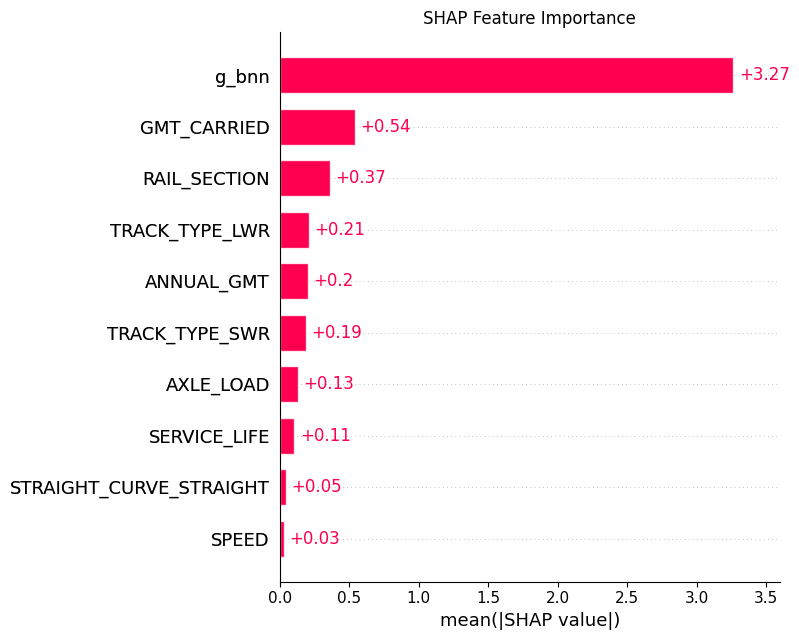

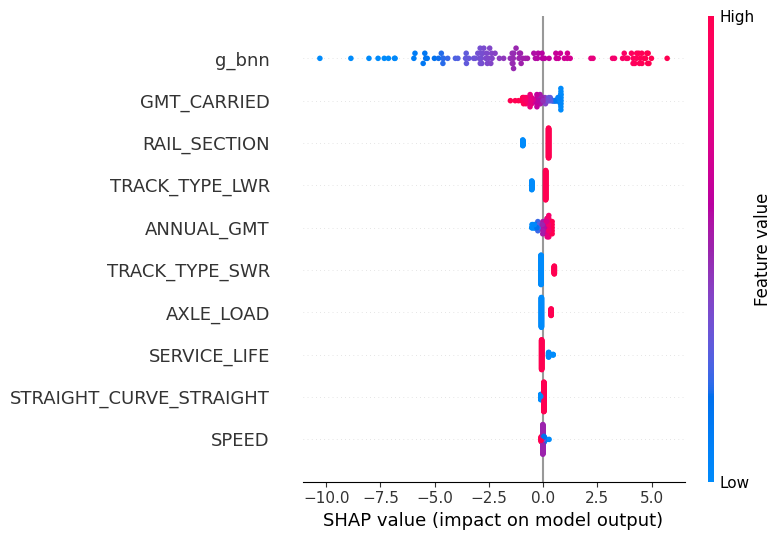

In [ ]:
# SHAP feature importance for the final Cox model

import shap
import matplotlib.pyplot as plt

feature_cols = list(cph_final.params_.index)


X_train_shap = train_df_final[feature_cols].copy()
X_test_shap = test_df_final[feature_cols].copy()

background = shap.sample(
    X_train_shap,
    min(100, len(X_train_shap)),
    random_state=RANDOM_STATE
)

X_explain = shap.sample(
    X_test_shap,
    min(200, len(X_test_shap)),
    random_state=RANDOM_STATE
)

def predict_log_risk(x):
    x_df = pd.DataFrame(x, columns=feature_cols)
    return cph_final.predict_log_partial_hazard(x_df).to_numpy().ravel()

explainer = shap.Explainer(
    predict_log_risk,
    shap.maskers.Independent(background),
    feature_names=feature_cols
)

shap_values = explainer(X_explain)

importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Mean_abs_SHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("Mean_abs_SHAP", ascending=False).reset_index(drop=True)

print("SHAP Feature Importance:")
display(importance_df)

plt.figure(figsize=(8, 5))
shap.plots.bar(shap_values, max_display=len(feature_cols), show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values.values, X_explain, feature_names=feature_cols)


  PRIOR DISTRIBUTION  â€”  N(0, 1)
  Mean               : 0.0046
  Std Dev            : 0.9985
  Median             : 0.0077
  P(w < 0)           : 0.4970
  P(|w| > 2)         : 0.0445  (heavy-tail check)
  Log-prob at w=0    : -0.9189


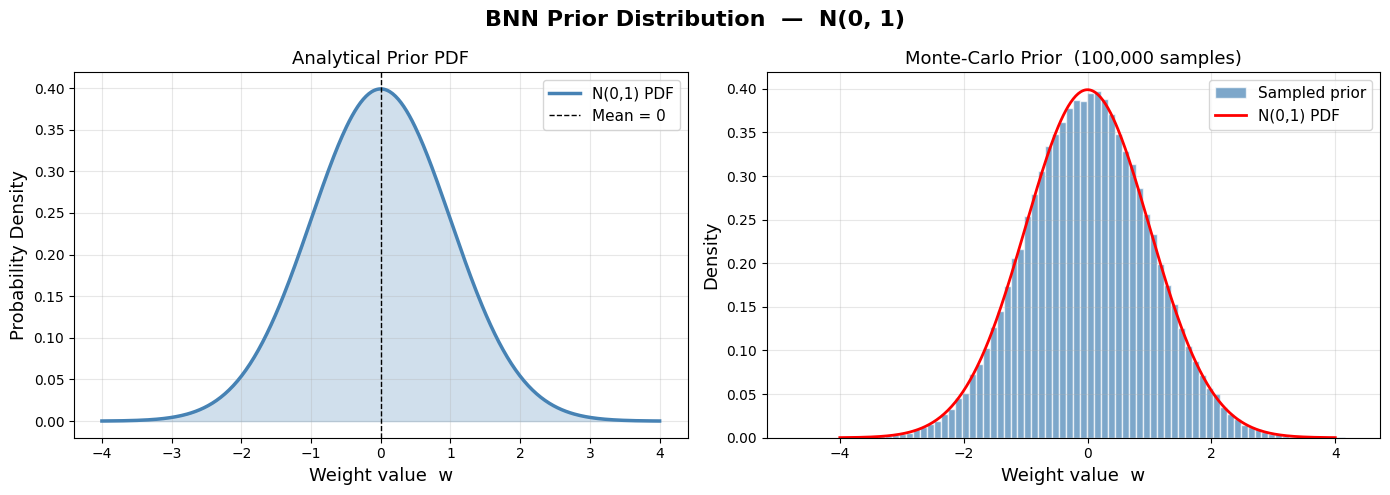

In [ ]:
# ==========================================================
# CELL: Prior Probability Distribution
# ==========================================================
# The BNN uses a standard Normal prior N(0, 1) on all weights/biases.
# This cell visualises that prior and computes summary statistics.

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import tensorflow_probability as tfp
import tensorflow as tf

tfd = tfp.distributions

# ----------------------------------------------------------
# 1. Define the prior distribution (same as prior_fn in the model)
# ----------------------------------------------------------
prior_dist = tfd.Normal(loc=0.0, scale=1.0)

# ----------------------------------------------------------
# 2. Draw samples to approximate the prior
# ----------------------------------------------------------
NUM_SAMPLES = 100_000
prior_samples = prior_dist.sample(NUM_SAMPLES).numpy()

# ----------------------------------------------------------
# 3. Summary statistics
# ----------------------------------------------------------
print("=" * 50)
print("  PRIOR DISTRIBUTION  â€”  N(0, 1)")
print("=" * 50)
print(f"  Mean               : {prior_samples.mean():.4f}")
print(f"  Std Dev            : {prior_samples.std():.4f}")
print(f"  Median             : {np.median(prior_samples):.4f}")
print(f"  P(w < 0)           : {(prior_samples < 0).mean():.4f}")
print(f"  P(|w| > 2)         : {(np.abs(prior_samples) > 2).mean():.4f}  (heavy-tail check)")
print(f"  Log-prob at w=0    : {float(prior_dist.log_prob(0.0)):.4f}")
print("=" * 50)

# ----------------------------------------------------------
# 4. Plot â€” PDF + histogram of samples
# ----------------------------------------------------------
w_grid = np.linspace(-4, 4, 400)
pdf_vals = prior_dist.prob(w_grid).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("BNN Prior Distribution  â€”  N(0, 1)", fontsize=16, fontweight="bold")

# Left: analytical PDF
ax = axes[0]
ax.plot(w_grid, pdf_vals, color="steelblue", lw=2.5, label="N(0,1) PDF")
ax.fill_between(w_grid, pdf_vals, alpha=0.25, color="steelblue")
ax.axvline(0, color="black", lw=1, linestyle="--", label="Mean = 0")
ax.set_xlabel("Weight value  w", fontsize=13)
ax.set_ylabel("Probability Density", fontsize=13)
ax.set_title("Analytical Prior PDF", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# Right: sampled histogram
ax = axes[1]
ax.hist(prior_samples, bins=80, density=True, color="steelblue",
        edgecolor="white", alpha=0.7, label="Sampled prior")
ax.plot(w_grid, pdf_vals, color="red", lw=2, label="N(0,1) PDF")
ax.set_xlabel("Weight value  w", fontsize=13)
ax.set_ylabel("Density", fontsize=13)
ax.set_title(f"Monte-Carlo Prior  ({NUM_SAMPLES:,} samples)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

  POSTERIOR DISTRIBUTION SUMMARY  (all weights + biases)
  Total parameters        : 3,585
  Posterior mean  â€” mean  : 0.0075
  Posterior mean  â€” std   : 0.1275
  Posterior scale â€” mean  : 0.101429
  Posterior scale â€” std   : 0.018402
  Posterior scale â€” min   : 0.000000
  Posterior scale â€” max   : 0.134387

  Per-layer summary:
  Layer                               Param        E[Î¼]   Std[Î¼]       E[Ïƒ]
  ---------------------------------------------------------------------------
  dense_reparameterization_21         kernel    -0.0062   0.1410   0.102809
  dense_reparameterization_21         bias       0.1005   0.1663   0.000000
  dense_reparameterization_22         kernel     0.0126   0.1116   0.105323
  dense_reparameterization_22         bias       0.1041   0.1589   0.000000
  dense_reparameterization_23         kernel    -0.0039   0.1780   0.098953
  dense_reparameterization_23         bias       0.0135   0.0000   0.000000


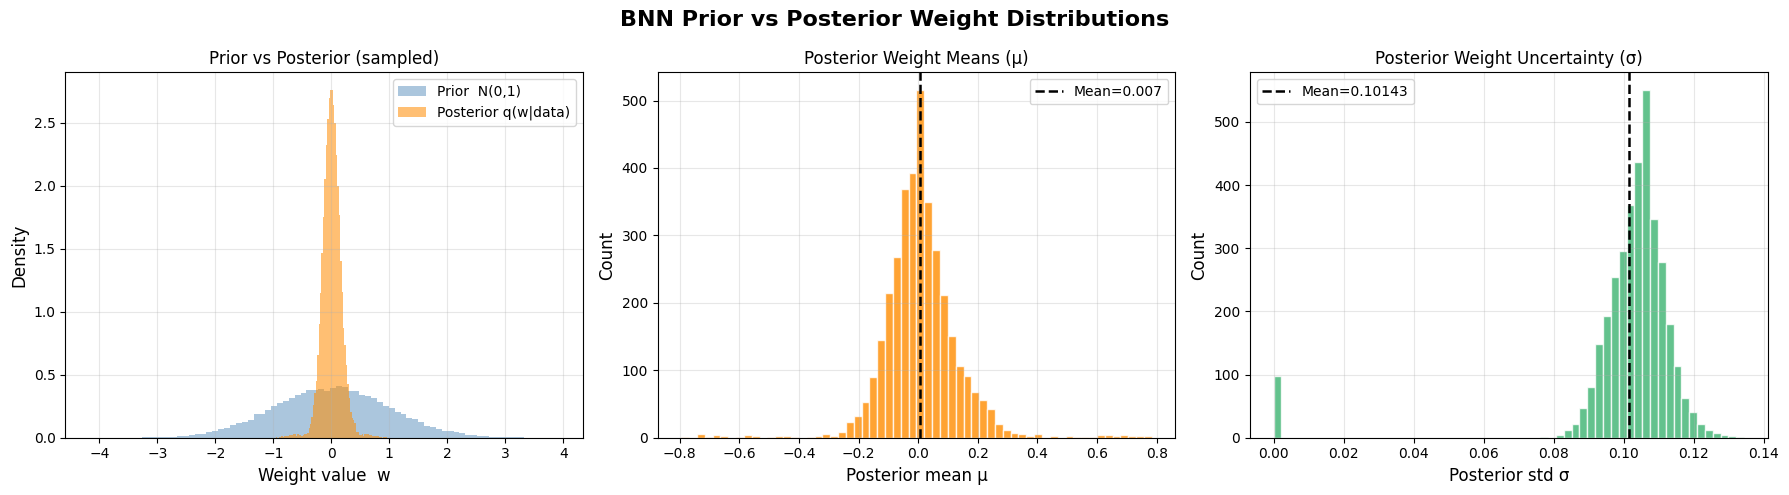


  KL Divergence  KL(q || p)  per layer:
  Layer                               Param              KL
  ------------------------------------------------------------
  dense_reparameterization_21         kernel      2524.9011
  dense_reparameterization_21         bias              inf
  dense_reparameterization_22         kernel      3613.8496
  dense_reparameterization_22         bias              inf
  dense_reparameterization_23         kernel        58.7326
  dense_reparameterization_23         bias              inf


In [ ]:
# ==========================================================
# CELL: Posterior Probability Distribution
# ==========================================================
# After training, each BNN weight has a Gaussian posterior q(w|data).
# The posterior is parameterised by (loc, scale) learned during training.
# This cell extracts those parameters from a trained model and visualises
# the posterior alongside the prior to show how the data updated beliefs.

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp

tfd = tfp.distributions

# ----------------------------------------------------------
# SAFETY CHECK: the BNN model must already be trained
# ----------------------------------------------------------
if "model_NCR" not in dir() and "g_tr_final" not in dir():
    raise RuntimeError(
        "Run the training cell(s) first so the BNN model is available."
    )

# Use whichever model variable is available
_bnn = model_NCR if "model_NCR" in dir() else None

if _bnn is None:
    print("WARNING: model_NCR not found. Falling back to posterior_fn defaults only.")
    post_loc_init   = 0.0
    post_scale_init = np.exp(-2.2)   # untransformed_scale_initializer = -2.2
    print(f"  Posterior loc  (init)  : {post_loc_init:.4f}")
    print(f"  Posterior scale (init) : {post_scale_init:.6f}")
else:
    # ----------------------------------------------------------
    # 1. Extract loc and scale from every DenseReparameterization layer
    # ----------------------------------------------------------
    layer_stats = []
    for layer in _bnn.layers:
        if isinstance(layer, tfp.layers.DenseReparameterization):
            kp = layer.kernel_posterior
            k_loc   = kp.mean().numpy().ravel()
            k_scale = kp.stddev().numpy().ravel()
            layer_stats.append({"name": layer.name, "param": "kernel",
                                 "loc": k_loc, "scale": k_scale})
            bp = layer.bias_posterior
            b_loc   = bp.mean().numpy().ravel()
            b_scale = bp.stddev().numpy().ravel()
            layer_stats.append({"name": layer.name, "param": "bias",
                                 "loc": b_loc, "scale": b_scale})

    # ----------------------------------------------------------
    # 2. Aggregate all posterior parameters
    # ----------------------------------------------------------
    all_locs   = np.concatenate([s["loc"]   for s in layer_stats])
    all_scales = np.concatenate([s["scale"] for s in layer_stats])

    print("=" * 60)
    print("  POSTERIOR DISTRIBUTION SUMMARY  (all weights + biases)")
    print("=" * 60)
    print(f"  Total parameters        : {len(all_locs):,}")
    print(f"  Posterior mean  â€” mean  : {all_locs.mean():.4f}")
    print(f"  Posterior mean  â€” std   : {all_locs.std():.4f}")
    print(f"  Posterior scale â€” mean  : {all_scales.mean():.6f}")
    print(f"  Posterior scale â€” std   : {all_scales.std():.6f}")
    print(f"  Posterior scale â€” min   : {all_scales.min():.6f}")
    print(f"  Posterior scale â€” max   : {all_scales.max():.6f}")
    print("=" * 60)

    # ----------------------------------------------------------
    # 3. Per-layer breakdown
    # ----------------------------------------------------------
    print("\n  Per-layer summary:")
    print(f"  {'Layer':<35} {'Param':<8} {'E[Î¼]':>8} {'Std[Î¼]':>8} {'E[Ïƒ]':>10}")
    print("  " + "-" * 75)
    for s in layer_stats:
        print(f"  {s['name']:<35} {s['param']:<8} "
              f"{s['loc'].mean():>8.4f} {s['loc'].std():>8.4f} "
              f"{s['scale'].mean():>10.6f}")

    # ----------------------------------------------------------
    # 4. Sample from prior and posterior for comparison
    # ----------------------------------------------------------
    NUM_SAMPLES = 50_000
    prior_samples = np.random.normal(0, 1, NUM_SAMPLES)
    idx = np.random.randint(0, len(all_locs), NUM_SAMPLES)
    posterior_samples = np.random.normal(all_locs[idx], all_scales[idx])

    # ----------------------------------------------------------
    # 5. Visualisation
    # ----------------------------------------------------------
    w_grid    = np.linspace(-4, 4, 400)
    prior_pdf = tfd.Normal(0., 1.).prob(w_grid).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("BNN Prior vs Posterior Weight Distributions",
                 fontsize=16, fontweight="bold")

    # Panel A: Prior vs Posterior overlay
    ax = axes[0]
    ax.hist(prior_samples,     bins=80, density=True, alpha=0.45,
            color="steelblue",  label="Prior  N(0,1)")
    ax.hist(posterior_samples, bins=80, density=True, alpha=0.55,
            color="darkorange", label="Posterior q(w|data)")
    ax.set_xlabel("Weight value  w", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title("Prior vs Posterior (sampled)", fontsize=12)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    # Panel B: Posterior means Î¼
    ax = axes[1]
    ax.hist(all_locs, bins=60, color="darkorange", edgecolor="white", alpha=0.8)
    ax.axvline(all_locs.mean(), color="black", lw=1.8, linestyle="--",
               label=f"Mean={all_locs.mean():.3f}")
    ax.set_xlabel("Posterior mean Î¼", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title("Posterior Weight Means (Î¼)", fontsize=12)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    # Panel C: Posterior uncertainty Ïƒ
    ax = axes[2]
    ax.hist(all_scales, bins=60, color="mediumseagreen", edgecolor="white", alpha=0.8)
    ax.axvline(all_scales.mean(), color="black", lw=1.8, linestyle="--",
               label=f"Mean={all_scales.mean():.5f}")
    ax.set_xlabel("Posterior std Ïƒ", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.set_title("Posterior Weight Uncertainty (Ïƒ)", fontsize=12)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ----------------------------------------------------------
    # 6. KL-Divergence per layer  KL(q || p)
    # ----------------------------------------------------------
    print("\n  KL Divergence  KL(q || p)  per layer:")
    print(f"  {'Layer':<35} {'Param':<8} {'KL':>12}")
    print("  " + "-" * 60)
    for s in layer_stats:
        q  = tfd.Normal(loc=s["loc"], scale=s["scale"])
        p  = tfd.Normal(loc=np.zeros_like(s["loc"]), scale=np.ones_like(s["scale"]))
        kl = float(tf.reduce_sum(tfd.kl_divergence(q, p)).numpy())
        print(f"  {s['name']:<35} {s['param']:<8} {kl:>12.4f}")